In [9]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tickers = ["SPY", "GLD"]

df = yf.download(tickers, start="2023-01-01", end="2024-01-01", auto_adjust=True)

# keep adjusted close prices only
prices = df["Close"].copy()

# quick check
print(prices.head())
print(prices.columns)

[*********************100%***********************]  2 of 2 completed

Ticker             GLD         SPY
Date                              
2023-01-03  171.059998  365.072052
2023-01-04  172.669998  367.890472
2023-01-05  170.520004  363.691620
2023-01-06  173.710007  372.031830
2023-01-09  174.100006  371.820923
Index(['GLD', 'SPY'], dtype='object', name='Ticker')


In [3]:
portfolio_value = 15000

w_spy = 0.7
w_gld = 0.3

# initial prices (first row)
P0_spy = prices.iloc[0]["SPY"]
P0_gld = prices.iloc[0]["GLD"]

# capital allocation
investment_spy = portfolio_value * w_spy
investment_gld = portfolio_value * w_gld

# number of shares
shares_spy = investment_spy / P0_spy
shares_gld = investment_gld / P0_gld

print("Initial SPY price:", P0_spy)
print("Initial GLD price:", P0_gld)
print("Shares SPY:", shares_spy)
print("Shares GLD:", shares_gld)

Initial SPY price: 365.0720520019531
Initial GLD price: 171.05999755859375
Shares SPY: 28.7614456993378
Shares GLD: 26.306559477522498


In [4]:
# Compute daily returns
returns = prices.pct_change().dropna()

# Portfolio return (reuse weights)
returns["portfolio"] = w_spy * returns["SPY"] + w_gld * returns["GLD"]

print(returns.head())

Ticker           GLD       SPY  portfolio
Date                                     
2023-01-04  0.009412  0.007720   0.008228
2023-01-05 -0.012451 -0.011413  -0.011725
2023-01-06  0.018707  0.022932   0.021665
2023-01-09  0.002245 -0.000567   0.000277
2023-01-10  0.003676  0.007013   0.006012


In [6]:
import numpy as np

sigma_spy = returns["SPY"].std(ddof=1)
sigma_gld = returns["GLD"].std(ddof=1)

cov_sg = returns[["SPY", "GLD"]].cov().loc["SPY", "GLD"]

sigma_port_formula = np.sqrt(
    (w_spy**2) * sigma_spy**2 +
    (w_gld**2) * sigma_gld**2 +
    2 * w_spy * w_gld * cov_sg
)

sigma_port_direct = returns["portfolio"].std(ddof=1)

print("SPY volatility:", sigma_spy)
print("GLD volatility:", sigma_gld)
print("Covariance:", cov_sg)
print("Portfolio vol (formula):", sigma_port_formula)
print("Portfolio vol (direct):", sigma_port_direct)

corr = returns["SPY"].corr(returns["GLD"])
print("Correlation SPY-GLD:", corr)

SPY volatility: 0.00824685172622907
GLD volatility: 0.00843868218822538
Covariance: 2.814141919822705e-07
Portfolio vol (formula): 0.006312875110481806
Portfolio vol (direct): 0.006312875110481806
Correlation SPY-GLD: 0.004043739573084889


Q2

Parametric approach using SMA 

SMA portfolio volatility: 0.006312875110481806
Parametric VaR (1%) in €: 220.63498511133912


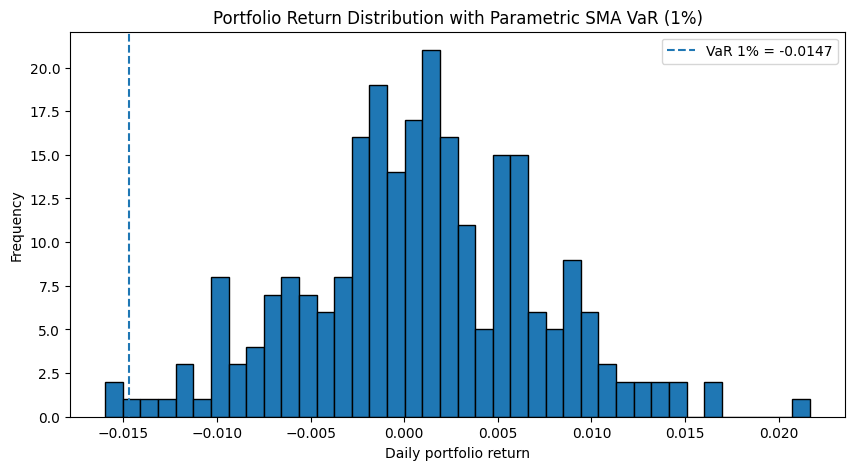

In [10]:
z_1 = 2.33   # 1% one-tailed critical value from the table 
portfolio_value = 15000

# SMA volatility = standard deviation of historical portfolio returns
sigma_sma = returns["portfolio"].std(ddof=1)

# With short-horizon assumption mu = 0
var_sma_pct = z_1 * sigma_sma
var_sma_eur = var_sma_pct * portfolio_value

print("SMA portfolio volatility:", sigma_sma)
print("Parametric VaR (1%) in €:", var_sma_eur)

plt.figure(figsize=(10, 5))
plt.hist(returns["portfolio"], bins=40, edgecolor="black")
plt.axvline(-var_sma_pct, linestyle="--", label=f"VaR 1% = {-var_sma_pct:.4f}")
plt.title("Portfolio Return Distribution with Parametric SMA VaR (1%)")
plt.xlabel("Daily portfolio return")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Methodology

The parametric Value at Risk (VaR) is estimated using the delta-normal (variance-covariance) approach. This method assumes that daily portfolio returns are normally distributed.

The daily portfolio volatility is estimated using the Simple Moving Average (SMA) method, meaning that all historical return observations are equally weighted.

For a 1% lower-tail VaR, the corresponding one-tailed critical value from the standard normal distribution is:

$$
z_{1\%} = 2.33
$$

Under the short-horizon assumption that the mean return is negligible ($\mu \approx 0$), the VaR is calculated as:

$$
VaR_{1\%} = z_{1\%} \cdot \sigma_p
$$

To express VaR in monetary terms, the percentage VaR is multiplied by the portfolio value ($V$):

$$
VaR_{1\%}^{\text{€}} = z_{1\%} \cdot \sigma_p \cdot V
$$

---

## Results

The estimated daily portfolio volatility is:

$$
\sigma_p = 0.00631
$$

Therefore, the daily VaR at the 1% level is:

$$
VaR_{1\%} = 2.33 \times 0.00631 = 0.0147
$$

This corresponds to:

$$
VaR_{1\%} = 1.47\%
$$

For a portfolio valued at €15,000:

$$
VaR_{1\%}^{\text{€}} = 0.0147 \times 15000 = 220.63
$$

---

## Interpretation

The parametric SMA VaR (1%) is estimated at €220.63, or 1.47% of the portfolio value.

This means that there is a 1% probability that the portfolio will experience a loss greater than €220.63 in one day, and a 99% probability that the loss will be smaller than this amount.

The relatively moderate level of VaR reflects the diversification benefits of combining an equity index (SPY) with gold (GLD), which tends to have different risk drivers.

---

## Comment

The parametric SMA approach is simple and computationally efficient. However, it relies on the assumption that returns are normally distributed, which may not hold in practice.

Financial returns often exhibit fat tails and skewness, meaning that extreme losses can occur more frequently than predicted by the normal distribution. As a result, the parametric VaR may underestimate tail risk, especially during periods of market stress.

---

## Plot

The histogram below shows the empirical distribution of daily portfolio returns. The dashed vertical line represents the VaR (1%) threshold.

Values to the left of the line correspond to extreme losses beyond the VaR estimate.



Lambda: 0.94
EWMA portfolio volatility: 0.006021076977394256
Parametric EWMA VaR (1%) in %: 0.014029109357328618
Parametric EWMA VaR (1%) in €: 210.43664035992927


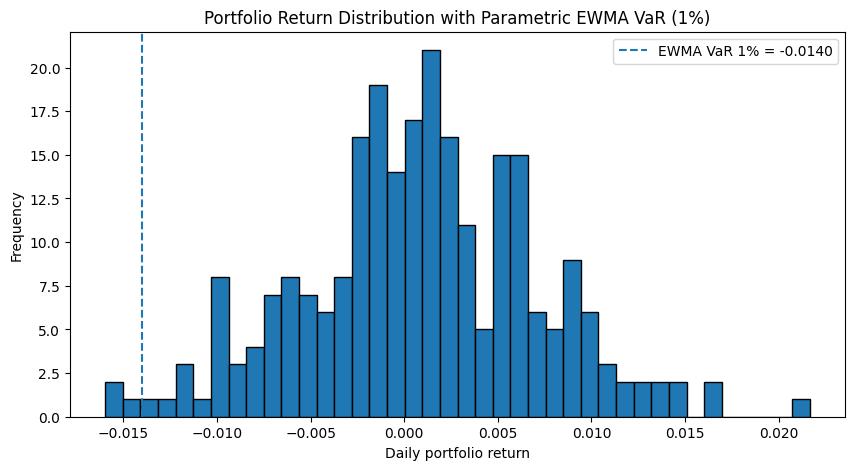

In [13]:
# Q2b - Parametric VaR using EWMA

lambda_ewma = 0.94
z_1 = 2.33
portfolio_value = 15000

r = returns["portfolio"].values
n = len(r)

# Exponentially decaying weights
weights = np.array([(1 - lambda_ewma) * (lambda_ewma ** i) for i in range(n)])
weights = weights / weights.sum()

# Match largest weight to most recent return
r_recent_first = r[::-1]

# EWMA variance and volatility
sigma_ewma_sq = np.sum(weights * (r_recent_first ** 2))
sigma_ewma = np.sqrt(sigma_ewma_sq)

# VaR
var_ewma_pct = z_1 * sigma_ewma
var_ewma_eur = var_ewma_pct * portfolio_value

print("Lambda:", lambda_ewma)
print("EWMA portfolio volatility:", sigma_ewma)
print("Parametric EWMA VaR (1%) in %:", var_ewma_pct)
print("Parametric EWMA VaR (1%) in €:", var_ewma_eur)

plt.figure(figsize=(10, 5))
plt.hist(returns["portfolio"], bins=40, edgecolor="black")
plt.axvline(-var_ewma_pct, linestyle="--", label=f"EWMA VaR 1% = {-var_ewma_pct:.4f}")
plt.title("Portfolio Return Distribution with Parametric EWMA VaR (1%)")
plt.xlabel("Daily portfolio return")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Methodology

The EWMA parametric VaR is estimated using the delta-normal approach, assuming that portfolio returns are normally distributed.

Unlike the SMA method, volatility is estimated using an Exponentially Weighted Moving Average (EWMA), which assigns greater weight to recent observations and less weight to older ones.

The EWMA variance is computed as:

$$
\sigma_{EWMA}^{2} = \sum_{t=1}^{n} w_t \, r_t^2
$$

where the weights decline exponentially based on the decay factor $\lambda$.

A value of:

$$
\lambda = 0.94
$$

is used, consistent with the industry-standard value and appropriate for a portfolio with moderately time-varying volatility.

The VaR is then calculated as:

$$
VaR_{1\%} = z_{1\%} \cdot \sigma_{EWMA}
$$

and in euro terms:

$$
VaR_{1\%}^{\text{€}} = z_{1\%} \cdot \sigma_{EWMA} \cdot V
$$

---

## Results

The EWMA volatility estimate is:

$$
\sigma_{EWMA} = 0.00602
$$

The daily VaR at the 1% level is:

$$
VaR_{1\%} = 2.33 \times 0.00602 = 0.01403
$$

This corresponds to:

$$
VaR_{1\%} = 1.40\%
$$

In euro terms:

$$
VaR_{1\%}^{\text{€}} = 0.01403 \times 15000 = 210.44
$$

---

## Interpretation

The EWMA VaR (1%) is estimated at €210.44, or 1.40% of portfolio value.

This indicates a 1% probability that the portfolio will lose more than €210.44 in one day.

---

## Comment

The EWMA VaR is slightly lower than the SMA VaR, suggesting that recent volatility is lower than the average volatility over the full sample period.

Because EWMA places greater weight on recent observations, it is more responsive to current market conditions than the SMA approach.


Number of observations: 249
1% rank position: 3
Historical VaR (1%) in %: 0.014927686068989952
Historical VaR (1%) in €: 223.91529103484928


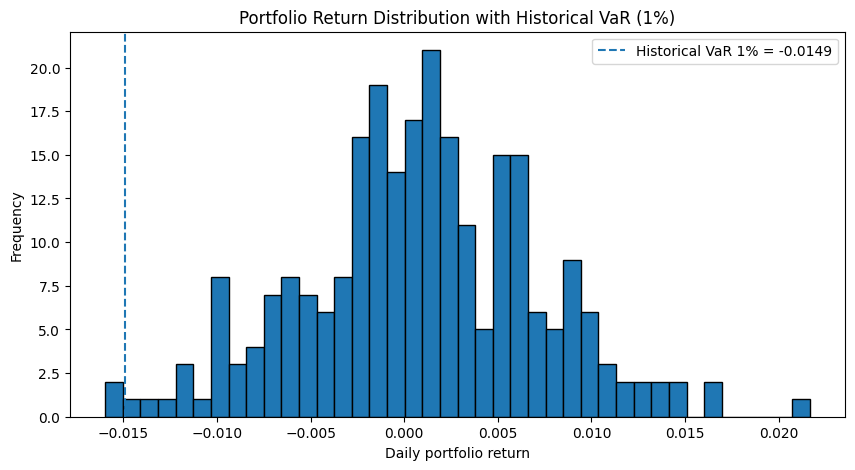

In [12]:
# Q2c - Historical Simulation VaR

sorted_returns = returns["portfolio"].sort_values().reset_index(drop=True)
n = len(sorted_returns)

# Position corresponding to 1% lower tail
k = int(np.ceil(0.01 * n))

# Since sorted ascending, the kth observation from the bottom
var_hist_return = abs(sorted_returns.iloc[k - 1])
var_hist_eur = var_hist_return * portfolio_value

print("Number of observations:", n)
print("1% rank position:", k)
print("Historical VaR (1%) in %:", var_hist_return)
print("Historical VaR (1%) in €:", var_hist_eur)

plt.figure(figsize=(10, 5))
plt.hist(returns["portfolio"], bins=40, edgecolor="black")
plt.axvline(-var_hist_return, linestyle="--", label=f"Historical VaR 1% = {-var_hist_return:.4f}")
plt.title("Portfolio Return Distribution with Historical VaR (1%)")
plt.xlabel("Daily portfolio return")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Methodology

The historical simulation approach estimates VaR directly from the empirical distribution of portfolio returns, without assuming any specific distribution.

Daily returns are ranked from lowest to highest, and the VaR at the 1% level is given by the return corresponding to the lowest 1% of observations:

[
VaR_{1%} = \text{1st percentile of historical returns}
]

The euro VaR is obtained by multiplying the percentage VaR by the portfolio value:

[
VaR_{1%}^{€} = VaR_{1%} \times V
]

---

## Results

The number of observations is:

[
N = 249
]

The 1% lower-tail corresponds to the:

[
k = 3^{rd} \text{ lowest return}
]

The estimated VaR is:

[
VaR_{1%} = 0.01493 = 1.49%
]

In euro terms:

[
VaR_{1%}^{€} = 0.01493 \times 15000 = 223.92
]

---

## Interpretation

The historical VaR (1%) is estimated at €223.92, or 1.49% of portfolio value.

This means that there is a 1% probability that the portfolio will lose more than €223.92 in one day, based purely on observed historical returns.

---

## Comment

Unlike the parametric approach, historical simulation does not rely on the normality assumption and instead reflects the actual distribution of returns.

The result is slightly higher than the parametric SMA VaR, suggesting the presence of mild non-normality or heavier tails in the return distribution. However, the estimate depends on the chosen sample period and may be sensitive to the absence or presence of extreme events.

